In [1]:
import cornac
from cornac.data import Reader
from cornac.datasets import movielens
from cornac.data import Dataset, FeatureModality
from cornac.eval_methods import RatioSplit, StratifiedSplit
from cornac.metrics import RMSE, AUC, NDCG, Precision, Recall
from cornac.models import MF, ItemKNN, UserKNN, NMF, BPR, LightGCN, SVD, MostPop, VAECF
import pandas as pd
import numpy as np
import random
import math
from collections import OrderedDict
import seaborn as sns
import matplotlib.pyplot as plt

/Users/tahsinalamgirkheya/anaconda3/envs/cornac/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
reader = Reader()
rating_data_pd = pd.read_csv(
    "./cornac/data_c/indexed_interactions.csv",
    sep="\t",
    header=None,
    names=["userID", "itemID", "Rating", "Timestamp"],
)
rating_data = rating_data_pd.to_numpy()
rating_data.__len__()
rating_data_pd


,userID,itemID,Rating,Timestamp
0,0,0,5,978300760
1,0,1,3,978302109
2,0,2,3,978301968
3,0,3,4,978300275
4,0,4,5,978824291
...,...,...,...,...
999606,6039,772,1,956716541
999607,6039,1106,5,956704887
999608,6039,365,5,956704746
999609,6039,152,4,956715648


In [3]:

movies = pd.read_csv("./cornac/data_c/indexed_movies.csv")

movies = movies.drop(columns=movies.columns[0])
movies[:4]

unique_genres = [
    "Action",
    "Thriller",
    "Romance",
    "Western",
    "Children's",
    "Mystery",
    "Fantasy",
    "Film-Noir",
    "Documentary",
    "Comedy",
    "Adventure",
    "Sci-Fi",
    "Horror",
    "Crime",
    "Musical",
    "War",
    "Animation",
    "Drama",
]
for genre in unique_genres:
    movies[genre] = 0
for index, row in movies.iterrows():
    genres = row["genres"].split("|")
    for genre in genres:
        movies.at[index, genre] = 1

genre = movies[unique_genres]
item_features_numpy = genre.to_numpy()
item_features = {
    str(item_id): {"genre_" + str(idx): value for idx, value in enumerate(row)}
    for item_id, row in enumerate(item_features_numpy)
}
ids = list(range(0, 3416))

users = pd.read_csv("./cornac/data_c/u_id_mapping.csv", sep="\t")
users = users.drop(columns=users.columns[0])
gender_map = {"M": 0, "F": 1}
users["Gender"] = users["Gender"].map(gender_map)
user_features_numpy = users.to_numpy()
print(user_features_numpy.shape)
print(item_features_numpy.shape)

(6040, 2)
(3416, 18)


In [4]:
dataset = rating_data
unique_genres.__len__()

18

In [5]:

movies = movies.sort_values(by="itemID")
movies

,movieID,genres,itemID,Action,Thriller,Romance,Western,Children's,Mystery,Fantasy,...,Documentary,Comedy,Adventure,Sci-Fi,Horror,Crime,Musical,War,Animation,Drama
0,1193,Drama,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,661,Animation|Children's|Musical,1,0,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0
2,914,Musical|Romance,2,0,0,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
3,3408,Drama,3,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,2355,Animation|Children's|Comedy,4,0,0,0,0,1,0,0,...,0,1,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3411,2833,Romance|War,3411,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3412,3207,Adventure,3412,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
3413,3533,Drama,3413,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3414,2777,Drama,3414,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [6]:
users

,Gender,userID
0,1,0
1,0,1
2,0,2
3,0,3
4,0,4
...,...,...
6035,1,6035
6036,1,6036
6037,1,6037
6038,1,6038


In [7]:
user_features_numpy[:,1]

array([   0,    1,    2, ..., 6037, 6038, 6039])

In [8]:
ratio_split = StratifiedSplit(
    data=dataset,
    test_size=0.2,
    val_size=0.1,
    rating_threshold=3,
    seed=123,
    verbose=True,
    chrono=True,
    user_features=user_features_numpy[:, 0],
    item_features=item_features_numpy,
    exclude_unknowns=False,
)
rec_50 = cornac.metrics.Recall(k=50)
ndcg_50 = cornac.metrics.NDCG(k=50)
auc = cornac.metrics.AUC()
rmse = cornac.metrics.RMSE()
prec = cornac.metrics.Precision(k=50)
hr = cornac.metrics.HitRatio(k=50)
mrr = cornac.metrics.MRR()
map = cornac.metrics.MAP()


model_1 = UserKNN(k=20, seed=123, verbose=True, name="user knn")
model_2 = ItemKNN(k=20, seed=123, verbose=True, name="item knn")
model_3 = MF(
    k=30,
    seed=123,
    name=f"a={0} mf",
    backend="pytorch",
    verbose=True,
    optimizer="adam",
    alpha=0,max_iter=40,batch_size=512,
    learning_rate=0.001
)
model_4 = VAECF(
    k=30,
    autoencoder_structure=[400],
    act_fn="relu",
    likelihood="bern",
    n_epochs=40,
    batch_size=512,
    learning_rate=0.001,
    beta=1.0,
    seed=123,alpha=0,
    verbose=True, name="a=0 vaecf"
)
model_5 = LightGCN(
    seed=123,
    verbose=True,
    emb_size=30,batch_size=512,
    num_epochs=40,alpha=0,
    early_stopping={"min_delta": 0.001, "patience": 20}, name="a=0 light_gcn"
)

models = [ model_1]
cornac.Experiment(
    ratio_split, models=models, metrics=[rec_50, ndcg_50, auc, rmse, prec, hr, mrr, map]
).run()

rating_threshold = 3.0
exclude_unknowns = False
::::::::
OrderedDict()
OrderedDict()
::::::::
---
Training data:
(array([   0,    0,    0, ..., 6039, 6039, 6039]), array([   0,    1,    2, ..., 2136, 1874,  734]), array([4., 5., 4., ..., 4., 5., 4.]))
Number of users = 6040
Number of items = 3415
Number of ratings = 694578
Max rating = 5.0
Min rating = 1.0
Global mean = 3.6
::::::::
OrderedDict([(6039, 0), (6038, 1), (6037, 2), (6036, 3), (6035, 4), (6034, 5), (6033, 6), (6032, 7), (6031, 8), (6030, 9), (6029, 10), (6028, 11), (6027, 12), (6026, 13), (6025, 14), (6024, 15), (6023, 16), (6022, 17), (6021, 18), (6020, 19), (6019, 20), (6018, 21), (6017, 22), (6016, 23), (6015, 24), (6014, 25), (6013, 26), (6012, 27), (6011, 28), (6010, 29), (6009, 30), (6008, 31), (6006, 32), (6007, 33), (6005, 34), (6004, 35), (6003, 36), (6002, 37), (6001, 38), (6000, 39), (5999, 40), (5998, 41), (5997, 42), (5996, 43), (5995, 44), (5994, 45), (5993, 46), (5992, 47), (5991, 48), (5990, 49), (5989, 50),

100%|██████████| 6040/6040 [00:00<00:00, 6867.08it/s]



[user knn] Evaluation started!


Rating:   5%|▍         | 9250/202336 [00:00<00:10, 18898.04it/s]


KeyboardInterrupt: 

In [4]:
g=[1,0,0,0]
u=[1,2]
g[[u]]

TypeError: list indices must be integers or slices, not list

In [20]:
user_ids = users.to_numpy()[:, 1]
item_ids = movies.to_numpy()[:, 2]
user_ids

array([   0,    1,    2, ..., 6037, 6038, 6039])

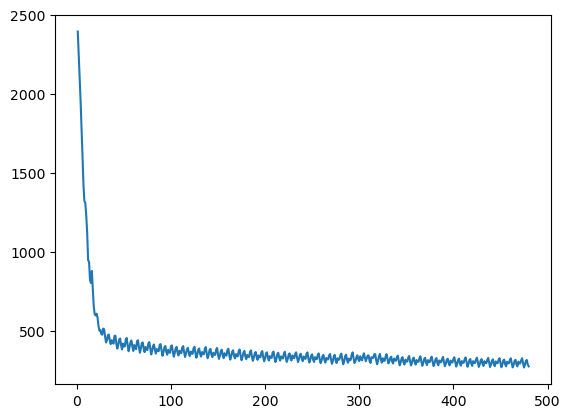

In [23]:
y = [2395.28369140625, 2250.343017578125, 2103.100341796875, 1954.5418701171875, 1790.4364013671875, 1613.031005859375, 1430.908447265625, 1322.1544189453125, 1309.237060546875, 1229.99560546875, 1119.428466796875, 946.783935546875, 934.947998046875, 821.5751342773438, 801.854248046875, 877.9882202148438, 757.2708740234375, 652.917724609375, 602.611572265625, 595.9473266601562, 607.3733520507812, 583.0228881835938, 529.7057495117188, 500.0644226074219, 504.0162353515625, 479.27630615234375, 474.1451416015625, 512.6998291015625, 508.4877014160156, 462.8192138671875, 424.4639892578125, 438.3037414550781, 471.1018981933594, 474.7745666503906, 438.5860900878906, 414.0838317871094, 439.24627685546875, 427.1675720214844, 417.411376953125, 466.8148193359375, 467.5793151855469, 416.4022521972656, 385.78436279296875, 408.9576721191406, 444.68609619140625, 449.8110046386719, 408.1406555175781, 380.1145935058594, 417.5126037597656, 399.6453552246094, 399.9979553222656, 444.1310729980469, 452.9009704589844, 406.9434814453125, 369.13006591796875, 395.7838439941406, 427.01055908203125, 437.03692626953125, 398.41961669921875, 370.968994140625, 408.7455749511719, 387.9236145019531, 382.8228454589844, 434.25872802734375, 438.43243408203125, 394.9661865234375, 359.6116638183594, 384.1712341308594, 420.37689208984375, 424.94415283203125, 388.38665771484375, 363.6895751953125, 396.52508544921875, 381.4425048828125, 376.2785949707031, 419.07037353515625, 426.8918762207031, 385.82421875, 348.656494140625, 372.3543395996094, 404.4556884765625, 411.7850341796875, 376.1620178222656, 354.1122131347656, 383.1937561035156, 371.62860107421875, 369.92083740234375, 409.60650634765625, 414.28338623046875, 374.27276611328125, 340.1345520019531, 362.577880859375, 393.05108642578125, 402.81842041015625, 365.186767578125, 346.5809631347656, 378.594482421875, 362.4378967285156, 359.2109680175781, 400.69476318359375, 406.27069091796875, 366.6934509277344, 334.8538818359375, 357.4796447753906, 387.74176025390625, 396.2066650390625, 359.5262756347656, 342.2537841796875, 373.1462097167969, 359.30908203125, 357.1765441894531, 393.2703857421875, 401.6877136230469, 361.85943603515625, 332.8504333496094, 356.0104675292969, 382.2417297363281, 391.11065673828125, 355.68426513671875, 337.8209228515625, 367.2540283203125, 355.168701171875, 352.29327392578125, 388.4880676269531, 397.0220642089844, 358.0480041503906, 327.9651794433594, 349.35406494140625, 379.7994689941406, 386.81146240234375, 351.7201843261719, 335.37286376953125, 364.75543212890625, 350.8217468261719, 351.34259033203125, 384.927734375, 395.199951171875, 353.0766906738281, 324.8783874511719, 345.3710021972656, 376.96697998046875, 384.3589172363281, 347.5591735839844, 332.0118713378906, 359.6281433105469, 346.88043212890625, 346.6730651855469, 379.81048583984375, 390.079345703125, 349.44384765625, 320.4086608886719, 340.5728759765625, 371.0655517578125, 378.88531494140625, 343.804443359375, 325.886962890625, 356.7521667480469, 343.4881591796875, 341.4920349121094, 377.23211669921875, 385.1300964355469, 344.9838562011719, 315.9619445800781, 337.53717041015625, 366.87322998046875, 374.9847412109375, 340.08551025390625, 323.7864074707031, 351.010009765625, 338.46490478515625, 337.1059265136719, 371.4999084472656, 380.4855651855469, 342.2070617675781, 312.2733154296875, 333.1849365234375, 360.8943786621094, 371.40838623046875, 335.96484375, 318.7961120605469, 346.06842041015625, 335.4786071777344, 332.700927734375, 364.7189025878906, 374.94598388671875, 334.8824157714844, 308.2797546386719, 328.12579345703125, 356.1824645996094, 364.3586730957031, 331.9329833984375, 314.72052001953125, 342.8796691894531, 331.3651123046875, 330.86785888671875, 361.81591796875, 370.3863220214844, 331.75531005859375, 305.6473388671875, 325.20611572265625, 356.1931457519531, 362.0878601074219, 327.0273132324219, 309.9134521484375, 338.46173095703125, 329.28106689453125, 327.08831787109375, 360.6889953613281, 366.9477844238281, 327.85552978515625, 301.08270263671875, 321.13702392578125, 351.7682189941406, 359.7912292480469, 327.45770263671875, 309.8310546875, 337.0720520019531, 325.5554504394531, 323.38128662109375, 354.53045654296875, 365.98321533203125, 329.2813415527344, 301.5015563964844, 319.18145751953125, 346.0237731933594, 355.83935546875, 322.71014404296875, 310.4502868652344, 342.8846435546875, 326.3256530761719, 324.89251708984375, 353.21044921875, 362.2660217285156, 326.7111511230469, 300.455810546875, 319.8084716796875, 346.7059020996094, 353.535888671875, 322.19195556640625, 305.9943542480469, 335.7470703125, 324.28472900390625, 320.84271240234375, 353.19012451171875, 361.7645568847656, 323.2125549316406, 297.81378173828125, 315.2194519042969, 341.42303466796875, 349.19964599609375, 315.8618469238281, 301.3824768066406, 331.86529541015625, 321.28802490234375, 319.8238525390625, 347.4353332519531, 355.448974609375, 318.3304138183594, 293.9056091308594, 310.41748046875, 338.3246154785156, 346.49493408203125, 313.2693786621094, 297.0887451171875, 327.1043701171875, 317.59552001953125, 317.9698486328125, 343.3172607421875, 351.8408203125, 317.2787780761719, 289.41790771484375, 308.3231506347656, 336.89251708984375, 345.78350830078125, 310.7573547363281, 295.1442565917969, 324.7098693847656, 315.09808349609375, 318.6198425292969, 345.2699890136719, 354.26055908203125, 316.7713928222656, 286.20806884765625, 305.7230224609375, 336.86273193359375, 347.6025390625, 314.5126953125, 296.0584411621094, 322.89971923828125, 311.0430603027344, 315.9533996582031, 347.06207275390625, 362.2283935546875, 325.13958740234375, 294.6611328125, 306.985595703125, 331.10504150390625, 343.48504638671875, 317.7099609375, 306.924560546875, 337.0428771972656, 317.87841796875, 311.7195129394531, 338.2808837890625, 356.129638671875, 328.06414794921875, 306.273681640625, 325.0577392578125, 341.83892822265625, 342.1381530761719, 306.6188049316406, 294.9316101074219, 331.4062805175781, 326.22369384765625, 327.82647705078125, 350.5600280761719, 350.24658203125, 311.81036376953125, 286.5763244628906, 309.5758972167969, 338.7910461425781, 352.079345703125, 316.15789794921875, 296.7812194824219, 324.9443664550781, 308.6685485839844, 308.7427673339844, 336.36431884765625, 350.41357421875, 319.29608154296875, 291.8228454589844, 304.5570068359375, 327.5372009277344, 334.6927795410156, 302.9472351074219, 291.53271484375, 323.1348876953125, 312.1919250488281, 308.9255676269531, 330.90264892578125, 341.58111572265625, 307.715576171875, 279.7392883300781, 297.61181640625, 323.4527893066406, 331.7101745605469, 299.45263671875, 285.0583801269531, 315.77490234375, 304.4857482910156, 303.5041198730469, 327.43408203125, 339.214111328125, 306.92828369140625, 279.4312744140625, 295.55487060546875, 321.74346923828125, 328.6123046875, 298.5451965332031, 284.6949157714844, 313.5069580078125, 303.04595947265625, 302.21246337890625, 325.83172607421875, 336.8748779296875, 303.89434814453125, 276.87408447265625, 294.9623107910156, 320.39141845703125, 327.8250427246094, 295.7511901855469, 281.6602783203125, 312.88641357421875, 300.5159912109375, 301.56854248046875, 323.902099609375, 335.4468994140625, 302.5230712890625, 275.47576904296875, 292.000244140625, 318.1342468261719, 325.9405517578125, 294.71148681640625, 280.1217956542969, 310.731201171875, 299.229248046875, 299.7223205566406, 320.55963134765625, 333.1063232421875, 301.43853759765625, 274.2064208984375, 290.9269104003906, 315.54888916015625, 322.16961669921875, 292.8459777832031, 279.7803039550781, 309.99383544921875, 298.17376708984375, 297.81243896484375, 319.96441650390625, 331.10455322265625, 300.03125, 272.0648498535156, 288.9688415527344, 313.9996337890625, 322.40081787109375, 291.2220153808594, 278.3177490234375, 306.9002685546875, 296.28424072265625, 297.0866394042969, 318.2584228515625, 330.3664245605469, 298.63934326171875, 270.6915283203125, 286.68951416015625, 312.6134033203125, 320.1278991699219, 290.6617736816406, 276.5019226074219, 306.4964294433594, 294.61724853515625, 295.3500061035156, 316.087646484375, 328.4506530761719, 297.59393310546875, 269.9235534667969, 286.20782470703125, 310.890625, 319.0968017578125, 288.7259826660156, 276.2405700683594, 306.2142333984375, 295.1911315917969, 293.66522216796875, 314.03509521484375, 327.0461730957031, 296.7214660644531, 269.27166748046875, 285.12884521484375, 309.3573913574219, 317.953125, 286.88653564453125, 274.6512145996094, 304.99755859375, 293.7665710449219, 293.8431396484375, 313.0394287109375, 325.2720031738281, 294.7535705566406, 267.5539245605469, 284.7673034667969, 310.1200256347656, 316.4525451660156, 286.47265625, 273.6667175292969, 302.995849609375, 293.1964111328125, 293.10845947265625, 312.8212585449219, 324.7623596191406, 293.5248107910156, 266.9602966308594, 282.8084411621094, 307.5541076660156, 315.20928955078125, 286.3711242675781, 273.2445983886719, 303.31964111328125, 291.83221435546875, 292.0367431640625, 311.38006591796875, 324.934814453125, 294.55804443359375, 266.3631286621094, 281.75067138671875, 306.70574951171875, 313.877685546875, 286.03887939453125, 273.5663757324219]


x = list(range(1, len(y)+1))
plt.plot(x,y)

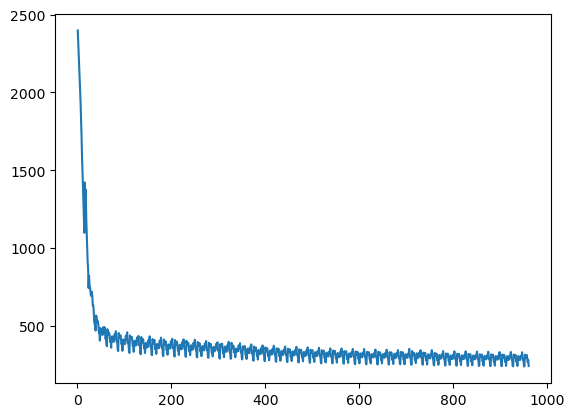

In [11]:
# get the top_k ratings for all users:
top_k = 50
reco_matrix = np.zeros((len(models), len(user_ids), top_k), dtype=int)
reco_matrix_mapped_items = np.zeros(
    (len(models), len(user_ids), len(item_ids)), dtype=int
)
reco_matrix_mapped_scores = np.zeros(
    (len(models), len(user_ids), len(item_ids)), dtype=float
)
reco_matrix_all = np.zeros((len(models), len(user_ids), len(item_ids)), dtype=int)


for u in user_ids:
    for i in range(len(models)):
        reco_items = models[i].recommend(u)
        items_mapped, mapped_scores = models[i].rank(
            user_idx=u, item_indices=list(item_ids)
        )
        reco_matrix_mapped_items[i][u] = items_mapped
        reco_matrix_mapped_scores[i][u] = mapped_scores
        reco_matrix_all[i][u] = reco_items
        reco_matrix[i][u] = reco_items[:top_k]

        # print(reco_matrix[0][3])

In [12]:
np.save("reco_matrix.npy", reco_matrix)
np.save("reco_matrix_mapped_items.npy", reco_matrix_mapped_items)
np.save("reco_matrix_mapped_scores.npy", reco_matrix_mapped_scores)
np.save("reco_matrix_all.npy", reco_matrix_all)
# np.save("reco_items_scores_all.npy", reco_items_scores_all)

# reco_matrix_all_items

In [13]:
####Import Metrics####
from cornac.mymetrics.GenrePrecision import GenrePrecision
from cornac.mymetrics.GenreMap import GenreMap
from cornac.mymetrics.GenreMRR import GenreMRR
from cornac.mymetrics.GenreNDCG import GenreNDCG
from cornac.mymetrics.GenreRecall import GenreRecall
from cornac.mymetrics.GenreRPrecision import GenreRPrecision

top_k = 50
###intialize them
gp = GenrePrecision(users, unique_genres, top_k)
gr = GenreRecall(users, unique_genres, top_k)
gm = GenreMap(users, unique_genres, top_k)
gndcg = GenreNDCG(users, unique_genres, top_k)
gmrr = GenreMRR(users, unique_genres, top_k)

In [14]:
# for r-precision we wanna take the max of the proportiion of total genre in the movie dataset using ranks
movies_df = movies[unique_genres].div(movies[unique_genres].sum(axis=1), axis=0)
movies_df = movies_df[unique_genres].sum()
new_top_k = math.floor(movies_df.max())


# get the top_k ratings for all users:
reco_matrix_top_r = np.zeros((reco_matrix.shape[0], len(user_ids), new_top_k), dtype=int)

for u in range(len(user_ids)):
    for i in range(reco_matrix.shape[0]):
        # reco_items, all_scores = models[i].rank(user_idx=user_ids[i], item_indices=list(item_ids))
        reco_matrix_top_r[i][u] = reco_matrix_all[i][u][:new_top_k]


grp = GenreRPrecision(users, unique_genres, top_k)
# MF_grp = grp.compute(reco_matrix_top_r, movies_df, movies)

In [15]:
####IR Metrics####
model_gps = []
model_grs = []
model_gms = []
model_gdcgs = []
model_gmrrs = []

for i in range(reco_matrix.shape[0]):
    ####Precision####
    model_gps.append(gp.compute(reco_matrix[i], movies))
    ####Recall####
    model_grs.append(gr.compute(reco_matrix[i], movies))
    ####MAP Mean Average Precision####
    model_gms.append(gm.compute(reco_matrix[i], movies))
    ####DCG####
    model_gdcgs.append(gndcg.compute(reco_matrix[i], movies))
    ####MRR####
    model_gmrrs.append(gmrr.compute(reco_matrix[i], movies))




In [16]:
# ####IR Metrics####
# ####Rprecision####
model_grps = []
for i in range(reco_matrix.shape[0]):
    model_grps.append(grp.compute(reco_matrix_top_r[i], movies_df, movies))

          Action  Thriller   Romance   Western  Children's   Mystery  Fantasy  \
Gender                                                                          
0       0.040212  0.092668  0.080516  0.000168    0.002974  0.011491      0.0   
1       0.038650  0.092238  0.083770  0.000263    0.003771  0.011563      0.0   

        Film-Noir  Documentary    Comedy  Adventure    Sci-Fi    Horror  \
Gender                                                                    
0        0.000762     0.041552  0.152715   0.014889  0.023551  0.002714   
1        0.000935     0.040293  0.153156   0.014372  0.021000  0.003275   

           Crime   Musical       War  Animation     Drama  
Gender                                                     
0       0.041116  0.000851  0.037107   0.086524  0.382513  
1       0.038294  0.001384  0.034535   0.086466  0.382377  
[[4.02120542e-02 9.26678752e-02 8.05156837e-02 1.68388825e-04
  2.97442451e-03 1.14905074e-02 0.00000000e+00 7.62146713e-04
  4.155223

In [17]:
from operator import itemgetter
from matplotlib.ticker import MultipleLocator

unique_genres
indices = [0, 1, 2, 11, 17]
compare_genres = itemgetter(*indices)(unique_genres)

list(compare_genres)

['Action', 'Thriller', 'Romance', 'Sci-Fi', 'Drama']

In [21]:
for m in models:
    print(m.name)

user knn
item knn
a=0 mf
a=0 vaecf
a=0 light_gcn


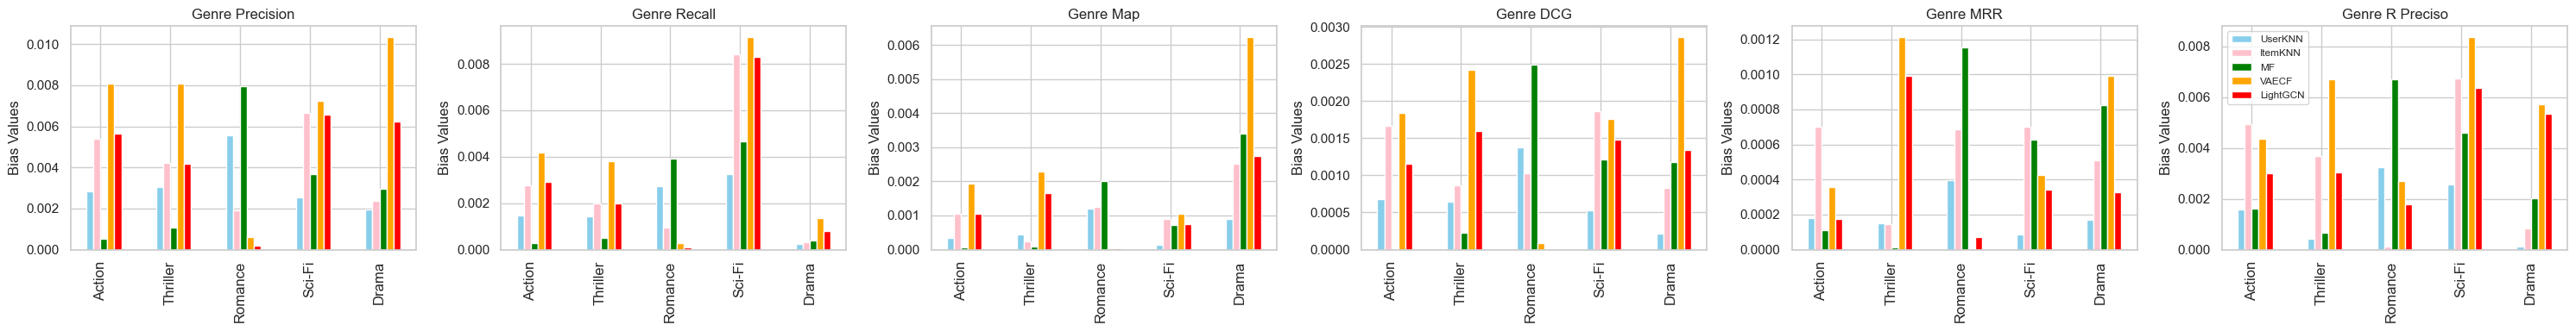

In [49]:
import matplotlib.pyplot as plt
import numpy as np
sns.set(style="whitegrid")

matrices = [
    model_gps[0][indices],
    model_grs[0][indices],
    model_gms[0][indices],
    model_gdcgs[0][indices],
    model_gmrrs[0][indices],
    model_grps[0][indices],
]
matrices_2 = [
    model_gps[1][indices],
    model_grs[1][indices],
    model_gms[1][indices],
    model_gdcgs[1][indices],
    model_gmrrs[1][indices],
    model_grps[1][indices],
]
matrices_3 = [
    model_gps[2][indices],
    model_grs[2][indices],
    model_gms[2][indices],
    model_gdcgs[2][indices],
    model_gmrrs[2][indices],
    model_grps[2][indices],
]
matrices_4 = [
    model_gps[3][indices],
    model_grs[3][indices],
    model_gms[3][indices],
    model_gdcgs[3][indices],
    model_gmrrs[3][indices],
    model_grps[3][indices],
]
matrices_5 = [
    model_gps[4][indices],
    model_grs[4][indices],
    model_gms[4][indices],
    model_gdcgs[4][indices],
    model_gmrrs[4][indices],
    model_grps[4][indices],
]

labels = compare_genres
titles = [
    "Genre Precision",
    "Genre Recall",
    "Genre Map",
    "Genre DCG",
    "Genre MRR",
    "Genre R Preciso",
]


fig, axs = plt.subplots(1, 6, figsize=(30, 4))
axs = axs.flatten()
x = np.arange(len(compare_genres))  # the label locations
bar_width = 0.1  # the width of the bars
# rects1 = ax.bar(x - 3*bar_width/2, gender_genre_weights_topk_recom.iloc[0]*100, bar_width, label='Female (Top 50)', color="#bca0dc")


for i in range(len(titles)):
    axs[i].bar(
        x - 3 * bar_width / 2, abs(matrices[i]), bar_width, color="skyblue", label="UserKNN"
    )
    axs[i].bar(
        x - 1 * bar_width / 2, abs(matrices_2[i]), bar_width, color="pink", label="ItemKNN"
    )
    axs[i].bar(
        x + 1 * bar_width / 2, abs(matrices_3[i]), bar_width, color="green", label="MF"
    )
    axs[i].bar(
        x + 3 * bar_width / 2, abs(matrices_4[i]), bar_width, color="orange", label="VAECF"
    )
    axs[i].bar(
        x + 5 * bar_width / 2, abs(matrices_5[i]), bar_width, color="red", label="LightGCN"
    )
    axs[i].set_xticks(x)
    axs[i].set_xticklabels(compare_genres, rotation=90, fontsize=12)
    axs[i].axhline(y=0, color='black', linewidth=0.5)
    axs[i].set_title(titles[i])
    # axs[i].set_xlabel("Genres")
    axs[i].set_ylabel("Bias Values")
    axs[i].tick_params(axis="x", rotation=90)
handles, labels = axs[0].get_legend_handles_labels()

plt.legend(handles, labels, loc="upper left", fontsize="8.5")

# Adjust layout
plt.tight_layout()
plt.savefig("100k_all.pdf", format="pdf")

plt.show()

In [50]:
gp_sum = [sum(abs(model_gps[i])) for i in range(len(models))]
gr_sum = [sum(abs(model_grs[i])) for i in range(len(models))]
gm_sum = [sum(abs(model_gms[i])) for i in range(len(models))]
gdcg_sum = [sum(abs(model_gdcgs[i])) for i in range(len(models))]
gmrr_sum = [sum(abs(model_gmrrs[i])) for i in range(len(models))]
grp_sum = [sum(abs(model_grps[i])) for i in range(len(models))]


In [51]:
gp_sum

[0.028300246022634045,
 0.06752932095149575,
 0.04735875567218856,
 0.05284490004191491,
 0.03687868350554912]

In [52]:
gr_sum

[0.034043719068074636,
 0.0748939934632972,
 0.06987493575527312,
 0.05216615587493526,
 0.03724239502499824]

In [53]:
gm_sum

[0.004021374128561666,
 0.017608614236904463,
 0.011822017946587398,
 0.013762529646796352,
 0.008962711529850266]

In [54]:
gdcg_sum

[0.006307287442772572,
 0.01814120828837455,
 0.015313039322092397,
 0.014423979533454132,
 0.010116629145957453]

In [55]:
gmrr_sum

[0.0017327635402781386,
 0.007073451173631905,
 0.008049846747490432,
 0.005663659699868925,
 0.004191425829967416]

In [56]:
grp_sum

[0.01783365942987277,
 0.05677678804875648,
 0.052220792862854824,
 0.0487881592877394,
 0.03589207028059627]